In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("hpi_data_gujarat.csv")
df.head()

,Cd,F,Zn,Pb,Na,K,Ni,Mn,Cu,Fe,HPI
0,152.943347,0.045660,0.006338,63.950104,0.003791,0.783432,114.780168,0.549903,0.011537,0.104738,118.815542
1,380.532151,0.376635,0.006557,9.906597,0.000123,0.723981,88.501003,0.324487,0.004008,0.195227,180.833627
2,294.137607,0.383038,0.006354,56.067760,0.000111,0.048207,42.390169,0.103193,0.013470,0.025984,154.516146
3,241.470101,0.449827,0.006177,175.746385,0.001618,0.518459,35.584270,0.420580,0.010714,0.004373,127.359105
4,66.627363,0.511003,0.006241,127.584516,0.002443,0.576491,41.964388,0.478024,0.020959,0.154261,95.499938


In [4]:
df.describe()

,Cd,F,Zn,Pb,Na,K,Ni,Mn,Cu,Fe,HPI
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,200.605817,0.362474,0.006942,156.810371,0.002501,0.737761,60.481347,0.305011,0.015883,0.103261,136.637603
std,116.264513,0.208787,0.000567,88.446755,0.001461,0.431755,34.240120,0.168401,0.008056,0.059639,56.882186
min,6.999326,0.017478,0.006009,3.902990,0.000025,0.021269,0.386192,0.010923,0.002004,0.001002,4.122742
25%,99.436918,0.182234,0.006420,79.193770,0.001186,0.357574,30.654936,0.173109,0.009787,0.050767,94.096435
50%,207.128503,0.369975,0.006906,164.820989,0.002474,0.743831,62.247878,0.312380,0.015625,0.102763,136.608514
75%,303.959548,0.543606,0.007434,236.656987,0.003670,1.091616,90.889583,0.440555,0.022996,0.156308,176.124768
max,396.071271,0.699805,0.007994,299.384365,0.004997,1.495078,119.801701,0.597308,0.029939,0.198969,265.017326


In [5]:
X = df.drop(columns=["HPI"])
y = df["HPI"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(X_test_scaled)

In [10]:
r2 = model.score(X_test_scaled, y_test)
print("R2 Score:", r2)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

R2 Score: 0.8709940215116481
RMSE: 18.072560640179685


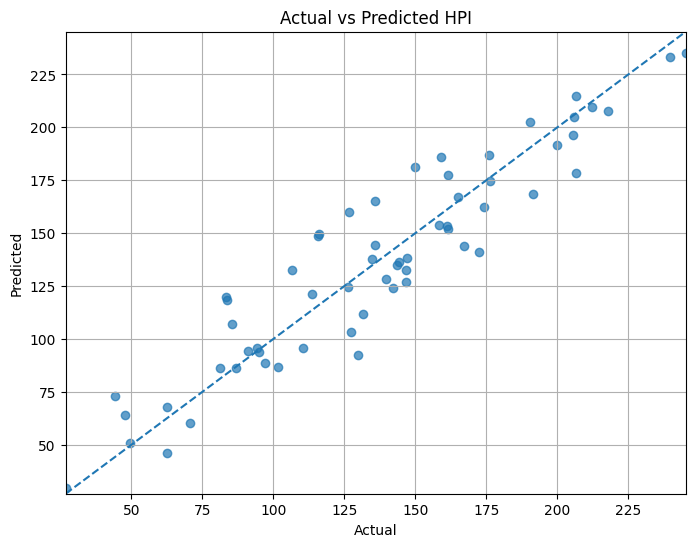

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted HPI")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(True)

plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

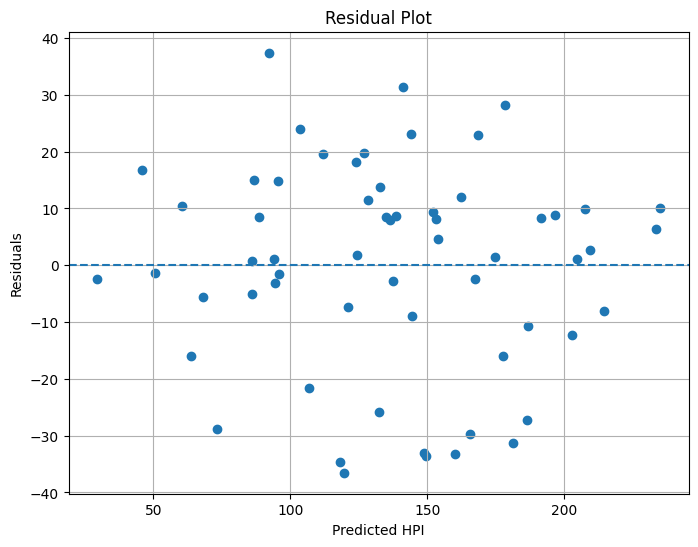

In [13]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, errors)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted HPI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

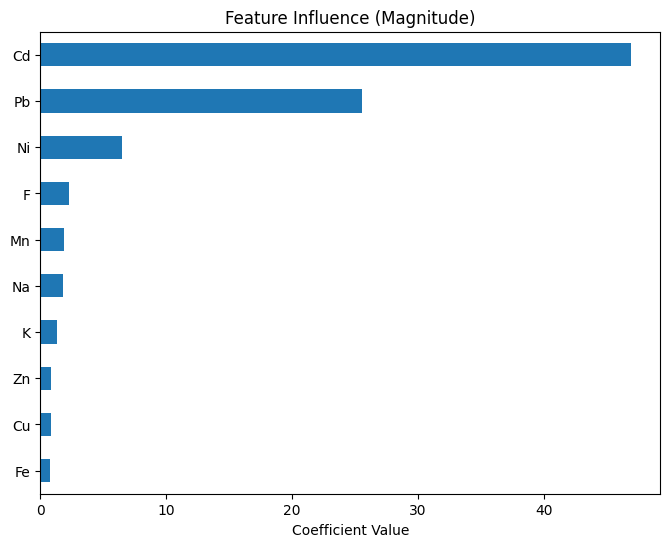

In [14]:
coeffs = pd.Series(model.coef_, index=X.columns)

plt.figure(figsize=(8,6))
coeffs.abs().sort_values().plot(kind='barh')

plt.title("Feature Influence (Magnitude)")
plt.xlabel("Coefficient Value")

plt.show()

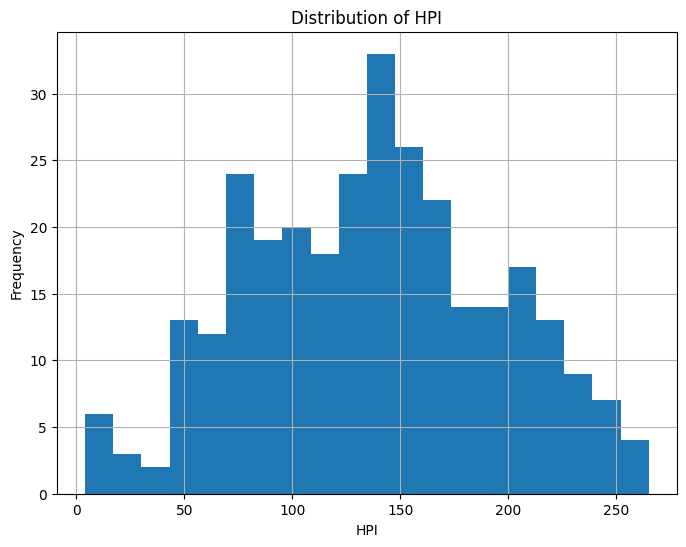

In [15]:
plt.figure(figsize=(8,6))

plt.hist(df["HPI"], bins=20)
plt.title("Distribution of HPI")
plt.xlabel("HPI")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

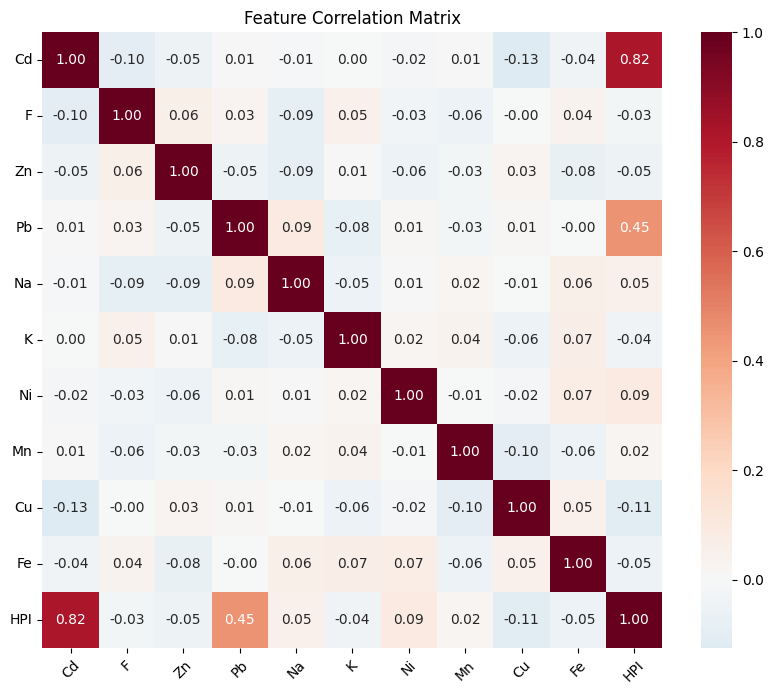

In [16]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

Dataset Description:

(Briefly describe the dataset used, including its source, size, and key features)

The dataset used in this study is based on groundwater samples collected from multiple monitoring stations across Gujarat. It represents an aggregated dataset of around 2000 samples, covering different regions and environmental conditions.

The dataset includes important parameters such as Cadmium (Cd), Fluoride (F), Zinc (Zn), Lead (Pb), Sodium (Na), Potassium (K), Nickel (Ni), Manganese (Mn), Copper (Cu), and Iron (Fe). These are commonly used to assess water quality and calculate the Heavy Metal Pollution Index (HPI).

The data was cleaned and organized to make it suitable for analysis. It captures variations in metal concentrations across locations, allowing effective prediction of HPI using machine learning.

For this study, a smaller subset of the dataset was used to apply linear regression. This subset was selected to focus on features that show meaningful correlation with HPI, making the model easier to analyze and interpret.


Data Preprocessing:

(Mention how the dataset was cleaned, normalized, or transformed for the model)

The original dataset contained groundwater measurements from different stations across Gujarat, including multiple heavy metal parameters. During preprocessing, unnecessary columns such as station identifiers and location-related data (latitude/longitude) were removed, as they were not directly useful for predicting HPI.

The dataset was checked for missing and inconsistent values, and cleaned to ensure all features were in a usable numeric format. The relevant features (metal concentrations) were then separated from the target variable (HPI).

To prepare the data for modeling, the dataset was split into training and testing sets. Additionally, feature values were scaled to bring all variables to a similar range, which helps improve the performance and stability of the linear regression model.

Brief Overview:

(Summarize the problem the case study is addressing)

The case study focuses on predicting the Heavy Metal Pollution Index (HPI) for groundwater. Traditionally, HPI is calculated using a complex weighted formula that involves multiple parameters and repeated calculations.

This manual process can be time-consuming and prone to errors, especially when dealing with large datasets from multiple monitoring stations.

To address this, the study uses machine learning (linear regression) to automatically predict HPI based on metal concentrations, making the process faster, more efficient, and scalable.

Key Objectives:

(List the key objectives of the case study)

* To analyze the relationship between **heavy metal concentrations and HPI**
* To build a **linear regression model** for predicting HPI
* To reduce the need for **manual calculation of HPI**
* To evaluate the model using metrics like **R² and RMSE**
* To understand which metals have the **most influence on HPI**



Approach:

(Explain the steps taken to solve the problem)

Here’s a clean, step-by-step version for your PPT:

* Collected and prepared the **groundwater dataset** with heavy metal parameters
* Performed **data preprocessing** by cleaning and selecting relevant features
* Explored the data using **visualizations** to understand relationships and correlations
* Split the dataset into **training and testing sets**
* Applied **multiple linear regression** to model the relationship between metals and HPI
* Evaluated the model using **R² and RMSE**
* Analyzed results using plots like **actual vs predicted and residual plots**



Algorithms Used:

(List the ML/AI algorithms or techniques applied and why)

Here’s a clean, PPT-ready version:

* **Multiple Linear Regression**
  Used to model the relationship between multiple heavy metal concentrations and HPI. It is simple, interpretable, and suitable since HPI is influenced by multiple input features.

* **Feature Scaling (Normalization/Standardization)**
  Applied to bring all features to a similar range, helping the model perform more efficiently and avoid bias toward larger values.

* **Train-Test Split**
  Used to divide the dataset into training and testing sets, ensuring the model is evaluated on unseen data.



Evaluation Metrics:

(Specify the metrics used to measure model’s performance)

* **R² Score (Coefficient of Determination)**
  Measures how well the model explains the variation in HPI. A higher value indicates better performance.

* **Root Mean Squared Error (RMSE)**
  Measures the average prediction error. Lower values indicate more accurate predictions.



Model Performance:

(Show key results, like accuracy, RMSE, precision, recall, etc.)


In [ ]:
# just use these socres ig, could write a bit about it but idk

r2 = model.score(X_test_scaled, y_test)
print("R2 Score:", r2)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

Graphs/Visualizations:

(Include graphs or charts that display model performance, feature importance, or predictions)

(There are multiple matplotlib graphs scattered around, so just paste all of them asndescribe them a bit, or describe what they describe)


Insights:

(What are the key insights from the model results?)

* The model shows a **strong relationship** between heavy metal concentrations and HPI
* Certain metals (like **Cd, Pb, and Ni**) have a **higher influence** on HPI compared to others
* The model is able to **predict HPI with reasonable accuracy** (R² ≈ 0.72)
* Some variation in predictions is observed due to **noise and real-world variability** in the data
* The approach successfully reduces the need for **manual HPI calculation**, making the process faster and scalable


Challenges Faced:

(Discuss any difficulties encountered during model building or data analysis)

* **Data availability** was a major challenge, as real-world groundwater datasets with complete heavy metal parameters are difficult to obtain
* The dataset contained **noise and variability**, making it harder to achieve very high accuracy
* **Multicollinearity** between some metals made it difficult to clearly interpret individual feature importance
* Ensuring proper **data preprocessing and scaling** required careful handling to avoid incorrect results
* Managing **model evaluation and validation** to avoid misleading results (like unrealistically high accuracy)


Sustainability Impact:

(How can the solution benefit the environment or contribute to sustainability goals?)

* Enables **faster and automated assessment** of water quality, reducing reliance on manual calculations
* Helps in **early detection of groundwater contamination**, supporting timely action
* Assists authorities in making **data-driven decisions** for water management
* Contributes to **public health protection** by identifying unsafe water sources
* Supports environmental monitoring aligned with **sustainable water resource management**


Practical Implementation:

(How can the solution be applied in real-world settings?)

* Can be integrated into **water quality monitoring systems** to quickly estimate HPI from measured metal concentrations
* Useful for **government agencies and environmental bodies** to monitor groundwater across regions
* Can be deployed as a **simple software tool or dashboard** for real-time analysis
* Helps reduce manual effort and allows **faster decision-making** in identifying contaminated areas
* Can be extended to support **large-scale monitoring** across multiple stations and time periods



Summary:

(Summarize the entire case study solution and its effectiveness)


This case study focused on predicting the **Heavy Metal Pollution Index (HPI)** using machine learning to reduce the need for complex manual calculations. A multiple linear regression model was built using heavy metal concentration data and evaluated using metrics like **R² and RMSE**.

The model achieved **reasonable accuracy** and was able to capture the relationship between metal concentrations and HPI. Although some variation exists due to real-world data noise, the approach proves to be **efficient, scalable, and practical**.

Overall, the solution demonstrates how machine learning can simplify environmental analysis and support **faster, data-driven decision-making** in water quality assessment.



Future Work:

(Any recommendations for future improvements or additional research)

* Explore more advanced models such as **Ridge, Lasso, or tree-based methods** to improve prediction accuracy
* Use a **larger and more diverse dataset** for better generalization
* Incorporate additional parameters like **pH, temperature, and dissolved solids**
* Develop a **real-time monitoring system or dashboard** for continuous prediction
* Perform deeper analysis to better understand **feature importance and interactions**

Paste your reference link here
(List all sources, datasets, and references used in the case study)

Paste thr pdf link from our whatapp group, and also the groundwater board smtg website

In [ ]:
# import seaborn as sns

# for col in ["Hg", "Cd", "Pb", "Cu"]:
#     sns.scatterplot(x=df[col], y=df["HPI"])
#     plt.title(f"{col} vs HPI")
#     plt.show()

In [18]:
# import seaborn as sns

# plt.figure(figsize=(10,8))
# sns.heatmap(df.corr(), annot=False)
# plt.title("Feature Correlation Matrix")
# plt.show()

In [19]:
# target = "HPI"

# features = df.columns.drop(target)

# for col in features:
#     if df[col].dtype != 'object':  # skip text columns
#         plt.figure()
#         plt.scatter(df[col], df[target])
#         plt.xlabel(col)
#         plt.ylabel(target)
#         plt.title(f"{col} vs {target}")
#         plt.show()

In [20]:
# numeric_df = df.select_dtypes(include=['number'])

# plt.figure(figsize=(10,8))
# sns.heatmap(numeric_df.corr(), annot=False)
# plt.title("Correlation Matrix")
# plt.show()

In [21]:
# for col in numeric_df.columns:
#     if col != "HPI":
#         sns.scatterplot(x=df[col], y=df["HPI"])
#         plt.title(f"{col} vs HPI")
#         plt.show()

In [22]:
print(df.corr()["HPI"].sort_values(ascending=False))

HPI    1.000000
Cd     0.819152
Pb     0.452445
Ni     0.092162
Na     0.053308
Mn     0.018496
F     -0.026250
K     -0.041780
Zn    -0.048542
Fe    -0.052787
Cu    -0.113343
Name: HPI, dtype: float64
